### Intro to Computational Math Capstone Project
Group number:

Members:
- My Pham (UFID: 12494292)
- 
- 

**1. Load the Dataset and Packages**

Load the Packages needed

In [11]:
from pathlib import Path
import pandas as pd
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Load the Dataset

In [ ]:
print("Notebook cwd:", os.getcwd())
name = "AmesHousing.csv"
# Common candidate locations (local, parent, data folders, home)
candidates = [
    Path.cwd() / name,
    Path.cwd().parent / name,
    Path.cwd() / "data" / name,
    Path.cwd().parent / "data" / name,
    Path.cwd().parent.parent / name,
    Path.home() / name,
]

found = None
tried = []
for p in candidates:
    tried.append(str(p))
    if p.exists():
        found = p
        break

# If still not found, do a limited rglob search from cwd and its parents (depth-limited)
if not found:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        try:
            for p in root.rglob(name):
                tried.append(str(p))
                found = p
                break
            if found:
                break
        except Exception:
            pass

if not found:
    msg = "AmesHousing.csv not found. Paths searched:\n" + "\n".join(tried)
    raise FileNotFoundError(msg)

csv_path = found
print("Using file:", csv_path)
df = pd.read_csv(csv_path)
print("Initial shape:", df.shape)
df.head()

Notebook cwd: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\code
Using file: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing.csv
Initial shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


**2. Data Cleaning**

In [5]:
# 1. Drop exact duplicate rows
before_shape = df.shape
df = df.drop_duplicates()
print(f"Dropped duplicates: {before_shape[0] - df.shape[0]} rows")

# 2. Drop columns with more than 50% missing values
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
if cols_to_drop:
    print("Dropping columns with >50% missing:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)
else:
    print("No columns with >50% missing to drop")

# 3. Fill numeric NaNs with median, categorical NaNs with mode (or 'Missing')
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for c in num_cols:
    if df[c].isnull().any():
        median = df[c].median()
        df[c] = df[c].fillna(median)

for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode()
        fill = mode[0] if not mode.empty else 'Missing'
        df[c] = df[c].fillna(fill)
    # strip whitespace for object columns
    if df[c].dtype == 'object':
        df[c] = df[c].str.strip()

# 4. Convert object columns with reasonably small cardinality to 'category' dtype
for c in cat_cols:
    try:
        if df[c].nunique(dropna=False) < 200:
            df[c] = df[c].astype('category')
    except Exception:
        pass

print("After cleaning shape:", df.shape)
print("Total remaining missing values:", df.isnull().sum().sum())
df.head()

Dropped duplicates: 0 rows
Dropping columns with >50% missing: ['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature']
After cleaning shape: (2930, 77)
Total remaining missing values: 0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900


Save the cleaned Dataframe to a new CSV file named 'AmesHousing_cleaned.csv'

In [6]:
output_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.2f} KB")

Cleaned dataset saved to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_cleaned.csv
File size: 945.25 KB


**3. Create modeling dataset using selected features**

In [ ]:
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

cols = features + [target]

# If df isn't in memory (kernel restart or out-of-order run), try to load cleaned CSV
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
    if cleaned_path.exists():
        print(f"'df' not found in memory — loading cleaned CSV from {cleaned_path}")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("'df' not defined and cleaned CSV not found. Run the data-loading/cleaning cells or create 'data/AmesHousing_cleaned.csv'.")

# Verify required columns exist in df
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for modeling dataset: {missing}")

model_df = df[cols].copy()
# Drop rows with missing values in these columns (should be none after cleaning)
before = model_df.shape[0]
model_df = model_df.dropna()
dropped = before - model_df.shape[0]
print(f"Modeling dataset shape: {model_df.shape} (dropped {dropped} rows)")
# Save modeling dataset
model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
model_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(model_path, index=False)
print(f"Saved modeling dataset to: {model_path}")
model_df.head()

Modeling dataset shape: (2930, 4) (dropped 0 rows)
Saved modeling dataset to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_model.csv


,Gr Liv Area,Overall Qual,Year Built,SalePrice
0,1656,6,1960,215000
1,896,5,1961,105000
2,1329,6,1958,172000
3,2110,7,1968,244000
4,1629,5,1997,189900


**4. Mathematical Work**

Compute correlation

Correlation matrix:
               Gr Liv Area  Overall Qual  Year Built  SalePrice
Gr Liv Area      1.000000      0.570556    0.241726   0.706780
Overall Qual     0.570556      1.000000    0.597027   0.799262
Year Built       0.241726      0.597027    1.000000   0.558426
SalePrice        0.706780      0.799262    0.558426   1.000000

Correlations with SalePrice:
SalePrice       1.000000
Overall Qual    0.799262
Gr Liv Area     0.706780
Year Built      0.558426
Name: SalePrice, dtype: float64


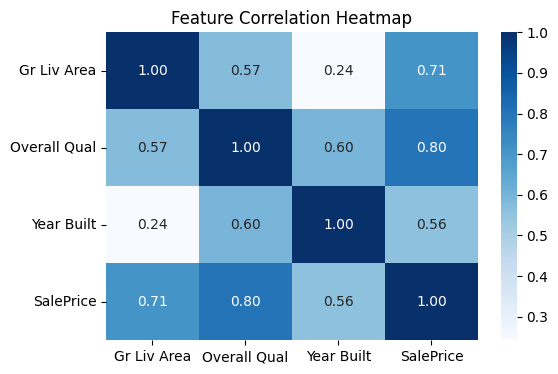

In [ ]:
# If model_df isn't in memory, try to load the saved modeling CSV
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Compute correlation
corr = model_df.corr()
print("Correlation matrix:\n", corr)

# Show correlations with SalePrice specifically
print("\nCorrelations with SalePrice:")
print(corr['SalePrice'].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

**Correlation analysis:** the printed correlation matrix and heatmap above show how `GrLivArea`, `OverallQual`, and `YearBuilt` relate to `SalePrice`.
- **Overall Quality (0.80)** has the strongest positive relationship with SalePrice, meaning homes with better construction and materials tend to sell for significantly higher prices. 
- **Gr Liv Area (0.71)** is also strongly correlated, indicating that larger homes generally cost more.
- **Year Built (0.56)** shows a moderate relationship, suggesting that newer homes are valued higher.

These results confirm that all three selected features are relevant and appropriate for our regression model.

Build the linear regression model

Regression coefficients (Normal Equation):
  Intercept: -1049260.808041
  Gr Liv Area: 63.102103
  Overall Qual: 26011.043709
  Year Built: 495.541590

Error metrics:
  MSE: 1568202535.0003
  RMSE: 39600.5371
  MAE: 27310.7452


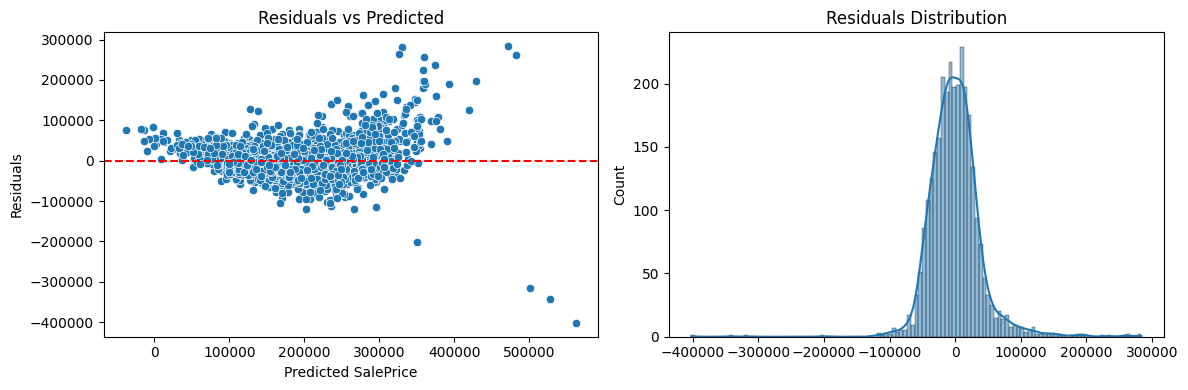

In [12]:
# Load or use existing modeling dataframe
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Features and target (assumes modeling CSV uses the canonical names)
features = [c for c in model_df.columns if c != 'SalePrice']
target = 'SalePrice'

# Build predictor matrix X and target vector y
X = model_df[features].astype(float).values
y = model_df[target].astype(float).values.reshape(-1,1)

# Add intercept column to design matrix
ones = np.ones((X.shape[0], 1))
X_design = np.hstack([ones, X])

# Compute coefficients using the Normal Equation (use pseudo-inverse for stability)
theta = np.linalg.pinv(X_design) @ y

# Show coefficients
coef_names = ['Intercept'] + features
print('Regression coefficients (Normal Equation):')
for name, val in zip(coef_names, theta.flatten()):
    print(f'  {name}: {val:.6f}')

# Make predictions and compute residuals
y_pred = X_design @ theta
residuals = (y - y_pred).flatten()

# Error metrics
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(residuals))
print('\nError metrics:')
print(f'  MSE: {mse:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE: {mae:.4f}')

# Plot residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=y_pred.flatten(), y=residuals, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution')
plt.tight_layout()
plt.show()